<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 2: PipelineTokenizacionNormalizaciónStemmerLematizacion</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> Crear una clase con un pipeline que tokenice, elimine stopwords, aplique stemming y lematizacion, y mida el impacto en el vocabulario.
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Crea tu propia clase para preprocesamiento de texto considerando Normalización de texto, Stemming/Lematización y Tokenización para un corpus en inglés y español</li>
<li>Procesa el corpus provisto de 4 textos en inglés y procesa el corpus de noticias en español</li>
<li>Calcula la reduccion de vocabulario en cada etapa</li>
<li>Visualiza los resultados con matplotlib</li>

</ul>
</div>

In [56]:
# Descarga de recursos de NLTK (ejecutar una sola vez)
import nltk

for recurso in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4',
                'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng']:
    nltk.download(recurso, quiet=True)

print("Recursos NLTK listos.")

Recursos NLTK listos.


In [71]:
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.corpus import stopwords
import string 
import unicodedata
import pandas as pd
import re

ETAPAS = ['original', 'normalizado', 'sin_stopwords', 'stem_lema']

class NLPTextCleaningPipeline:
    def __init__(self, idioma='spanish',
                 opciones_normalizar={"urls","correos","menciones","hashtags","numeros","emojis","puntuacion","espacios"},
                 remover_acentos=True, remover_stopwords=True,
                 normalizar_unicode=True, metodo_stem='snowball'):
        self.idioma = idioma
        self.stopwords = set(stopwords.words('spanish' if idioma == 'spanish' else 'english'))
        self.lenguaje_stem = idioma if idioma in SnowballStemmer.languages else 'english'
        self.stemmer = SnowballStemmer(self.lenguaje_stem)
        self.lematizer = WordNetLemmatizer()
        self.metodo = metodo_stem
        self.opciones_a_normalizar = opciones_normalizar
        self.remover_acentos = remover_acentos
        self.remover_stopwords = remover_stopwords

    # ---------- Etapas individuales ----------
    # -----------------------------------------
    
    def normalizar(self, texto):
        if self.opciones_a_normalizar is None:
            self.opciones_a_normalizar = {"urls", "correos", "menciones", "hashtags",
                                          "numeros", "emojis", "puntuacion", "espacios"}
        if "urls"       in self.opciones_a_normalizar: texto = re.sub(r'https?://\S+', '', texto)
        if "correos"    in self.opciones_a_normalizar: texto = re.sub(r'[\w.]+@[\w.]+\.[a-zA-Z]{2,}', '', texto)
        if "menciones"  in self.opciones_a_normalizar: texto = re.sub(r'@\w+', '', texto)
        if "hashtags"   in self.opciones_a_normalizar: texto = re.sub(r'#\w+', '', texto)
        if "numeros"    in self.opciones_a_normalizar: texto = re.sub(r'\S*\d\S*', '', texto)
        if "emojis"     in self.opciones_a_normalizar: texto = re.sub(r'[^\x00-\x7Fáéíóúüñ¡¿ÁÉÍÓÚÜÑa-zA-Z \n.,!?]', '', texto)
        if "puntuacion" in self.opciones_a_normalizar: texto = re.sub(r'[^\w\sáéíóúüñÁÉÍÓÚÜÑ]', ' ', texto, flags=re.UNICODE)
        if "espacios"   in self.opciones_a_normalizar: texto = re.sub(r'\s+', ' ', texto).strip()
        return texto.lower()

    def quitar_acentos(self, texto):
        nfkd = unicodedata.normalize('NFKD', texto)
        return ''.join(c for c in nfkd if not unicodedata.combining(c))

    def tokenizar(self, texto):
        # Tokeniza el texto YA normalizado: conserva solo tokens alfabéticos en minúscula
        return [w.lower() for w in texto.split() if w.isalpha()]

    def quitar_stopwords(self, tokens):
        return [t for t in tokens if t not in self.stopwords]

    def stemmeing(self, tokens):
        if self.metodo == 'porter':
            return [PorterStemmer().stem(t) for t in tokens]
        elif self.metodo == 'snowball':
            return [self.stemmer.stem(t) for t in tokens]
        else:
            return tokens

    def get_wn_pos(self, pos):
        # pos_tag devuelve etiquetas como 'VBD', 'NN', 'JJ'... usamos la primera letra
        inicial = pos[0] if pos else 'N'
        if inicial == 'V': return wordnet.VERB
        elif inicial == 'N': return wordnet.NOUN
        elif inicial == 'J': return wordnet.ADJ
        elif inicial == 'R': return wordnet.ADV
        else: return wordnet.NOUN

    def lematizar(self, texto):
        # Devuelve tuplas (token, POS, lema) — solo tiene sentido en inglés (WordNet)
        tokens = word_tokenize(texto.lower(), language=self.idioma)
        tagged = pos_tag(tokens)
        return [(t, tag, self.lematizer.lemmatize(t, pos=self.get_wn_pos(tag))) for t, tag in tagged]

    def lematizar_tokens(self, tokens):
        # Lematiza una lista de tokens y devuelve solo los lemas
        tagged = pos_tag(tokens)
        return [self.lematizer.lemmatize(t, pos=self.get_wn_pos(tag)) for t, tag in tagged]

    # ---------- Vocabulario por etapa ----------
    # -------------------------------------------
    def vocabulario_por_etapa(self, textos, metodo_final='stemming'):
        vocab = {etapa: set() for etapa in ETAPAS}
        for texto in textos:
            etapas = self.procesar(texto, metodo_final=metodo_final)
            for etapa in ETAPAS:
                vocab[etapa].update(etapas[etapa])
        tamanos = {etapa: len(vocab[etapa]) for etapa in ETAPAS}
        return tamanos, vocab


    # ---------- Pipeline integrado ----------
    # ----------------------------------------

    def procesar(self, texto, metodo_final='stemming'):
        """Ejecuta el pipeline completo y devuelve los tokens en cada etapa.
        metodo_final: 'stemming' o 'lematizacion'."""
        etapas = {}
        
        # 0. Texto original (tokenización simple, sin limpiar)
        etapas['original'] = [w.lower() for w in re.findall(r'\w+', texto, flags=re.UNICODE)]
        
        # 1. Normalización
        texto_norm = self.normalizar(texto)
        
        # 2. Tokenización
        tokens = self.tokenizar(texto_norm)
        etapas['normalizado'] = tokens
        
        # 3. Eliminación de stopwords  (se hace antes de quitar acentos para que coincidan)
        if self.remover_stopwords:
            tokens = self.quitar_stopwords(tokens)
        etapas['sin_stopwords'] = tokens        

        # 4. Quitar acentos (opcional)
        if self.remover_acentos:
            tokens = [self.quitar_acentos(t) for t in tokens]
    
        # 5. Stemming o Lematización
        if metodo_final == 'lematizacion':
            tokens = self.lematizar_tokens(tokens)
        else:
            tokens = self.stemmeing(tokens)
        etapas['stem_lema'] = tokens

        return etapas

    def preprocesar(self, texto, metodo_final='stemming'):
        # Devuelve la lista final de tokens limpios
        return self.procesar(texto, metodo_final)['stem_lema']


In [58]:
# Corpus simple en inglés
corpus_en = [
    {'Documento':'text_1','texto':'Natural language processing systems are becoming increasingly sophisticated.'},
    {'Documento':'text_2','texto':'Deep learning models have revolutionized text classification and generation tasks.'},
    {'Documento':'text_3','texto':'Tokenization is the fundamental first step in any NLP preprocessing pipeline.'},
    {'Documento':'text_4','texto':'Researchers are studying computational approaches to human language understanding.'},
]
df_corpus_en = pd.DataFrame(corpus_en)
df_corpus_en

,Documento,texto
0,text_1,Natural language processing systems are becomi...
1,text_2,Deep learning models have revolutionized text ...
2,text_3,Tokenization is the fundamental first step in ...
3,text_4,Researchers are studying computational approac...


In [62]:
#  Corpus de noticias en español
noticias = [
    {"categoria": "tecnología", "texto": "Apple presentó su nuevo chip M4 con IA integrada. La presentación fue en WWDC 2026 #Apple #M4"},
    {"categoria": "tecnología", "texto": "Google lanzó Gemini Ultra, su modelo más poderoso. Supera a GPT-4 en benchmarks https://blog.google.com"},
    {"categoria": "tecnología", "texto": "OpenAI anunció GPT-5 con capacidades multimodales avanzadas @OpenAI"},
    {"categoria": "economía",   "texto": "El peso mexicano se fortalece frente al dólar: $17.50 por USD en mercados internacionales"},
    {"categoria": "economía",   "texto": "La inflación en México cayó al 3.2% en abril 2026, según INEGI #Economia"},
    {"categoria": "economía",   "texto": "Inversión extranjera directa creció 15% en el primer trimestre del año"},
    {"categoria": "ciencia",    "texto": "Científicos descubrieron nueva especie de dinosaurio en Argentina #Paleontología"},
    {"categoria": "ciencia",    "texto": "Investigadores del MIT desarrollaron batería de estado sólido con carga en 5 minutos"},
    {"categoria": "ciencia",    "texto": "La NASA confirmó presencia de agua en la luna sur mediante misión Artemis https://nasa.gov"},
    {"categoria": "salud",      "texto": "Nuevo tratamiento contra el cáncer de páncreas muestra 80% de efectividad en ensayos clínicos"},
    {"categoria": "salud",      "texto": "OMS alerta sobre aumento de casos de resistencia a antibióticos en Latinoamérica #Salud"},
    {"categoria": "salud",      "texto": "Vacuna contra el dengue disponible en farmacias de México a partir de junio 2026"},
]

df_noticias_esp = pd.DataFrame(noticias)
df_noticias_esp

,categoria,texto
0,tecnología,Apple presentó su nuevo chip M4 con IA integra...
1,tecnología,"Google lanzó Gemini Ultra, su modelo más poder..."
2,tecnología,OpenAI anunció GPT-5 con capacidades multimoda...
3,economía,El peso mexicano se fortalece frente al dólar:...
4,economía,La inflación en México cayó al 3.2% en abril 2...
5,economía,Inversión extranjera directa creció 15% en el ...
6,ciencia,Científicos descubrieron nueva especie de dino...
7,ciencia,Investigadores del MIT desarrollaron batería d...
8,ciencia,La NASA confirmó presencia de agua en la luna ...
9,salud,Nuevo tratamiento contra el cáncer de páncreas...


In [ ]:
# E
# Calcular el vocabulario del original vs limpio
# Etc.

Aplicamos el pipeline completo a **los 4 textos en inglés** y a **las 12 noticias en español**, y medimos cuántas palabras únicas (vocabulario) sobreviven en cada etapa: *original → normalizado → sin stopwords → stemming/lematización*.

In [73]:

# Probamos los pilelines por idioma
# ------------------------------------------------

nlp_en = NLPTextCleaningPipeline(idioma='english')
nlp_es = NLPTextCleaningPipeline(idioma='spanish')

# Listas de textos de cada corpus
textos_en = df_corpus_en['texto'].tolist()
textos_es = df_noticias_esp['texto'].tolist()

# Ejemplo textos procesados en el pipeline
print("Texto Original Inglés")
print(df_corpus_en['texto'][0])
print("Texto procesado   (lematización):")
print(nlp_en.preprocesar(df_corpus_en['texto'][0], metodo_final='lematizacion'))
print("-------------------------")
print("Texto Original Español")
print(df_noticias_esp['texto'][0])
print("Texto procesado   (stemming):")
print(nlp_es.preprocesar(df_noticias_esp['texto'][0], metodo_final='stemming'))
print("")

# Inglés: usamos lematización; Español: stemming Snowball
tamanos_en, _ = nlp_en.vocabulario_por_etapa(textos_en, metodo_final='lematizacion')
tamanos_es, _ = nlp_es.vocabulario_por_etapa(textos_es, metodo_final='stemming')

# Tabla resumen con la reducción respecto al original
def tabla_reduccion(tamanos):
    base = tamanos['original']
    filas = []
    for etapa in ETAPAS:
        n = tamanos[etapa]
        filas.append({'etapa': etapa, 
                      'vocabulario': n,
                      'reduccion_%': round(100 * (base - n) / base, 1) if base else 0})
    return pd.DataFrame(filas)

print("Inglés (lematización):")
display(tabla_reduccion(tamanos_en))

print("\nEspañol (stemming):")
display(tabla_reduccion(tamanos_es))


Texto Original Inglés
Natural language processing systems are becoming increasingly sophisticated.
Texto procesado   (lematización):
['natural', 'language', 'processing', 'system', 'become', 'increasingly', 'sophisticated']
-------------------------
Texto Original Español
Apple presentó su nuevo chip M4 con IA integrada. La presentación fue en WWDC 2026 #Apple #M4
Texto procesado   (stemming):
['apple', 'present', 'nuev', 'chip', 'ia', 'integr', 'present', 'wwdc']

Inglés (lematización):


,etapa,vocabulario,reduccion_%
0,original,36,0.0
1,normalizado,36,0.0
2,sin_stopwords,28,22.2
3,stem_lema,28,22.2



Español (stemming):


,etapa,vocabulario,reduccion_%
0,original,118,0.0
1,normalizado,100,15.3
2,sin_stopwords,84,28.8
3,stem_lema,82,30.5


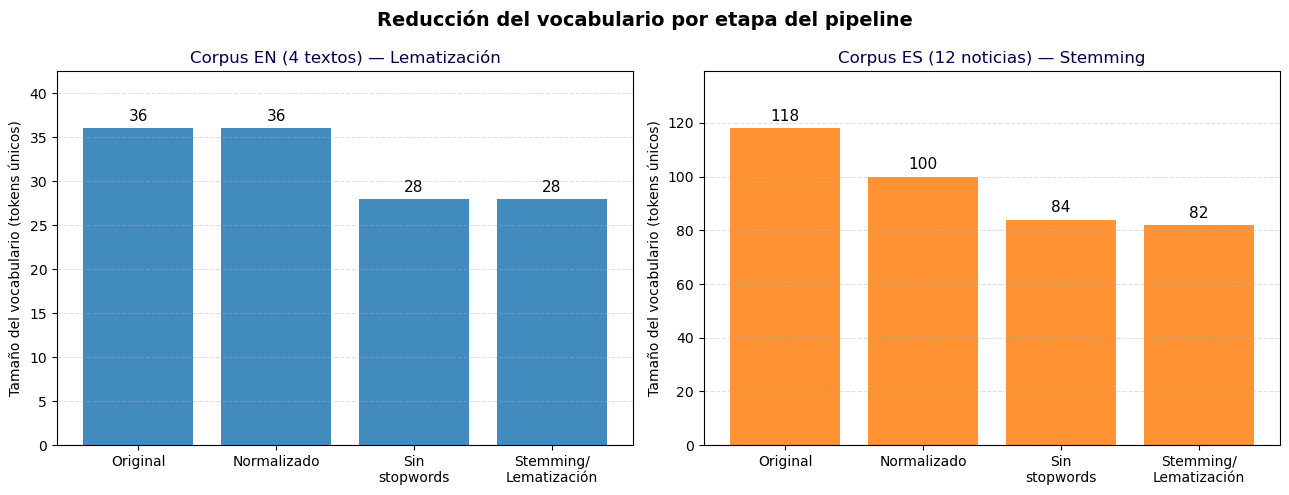

Reducción total del vocabulario  ->  Inglés: 22.2%   |   Español: 30.5%


In [74]:
import matplotlib.pyplot as plt
import numpy as np

etiquetas = ['Original', 'Normalizado', 'Sin\nstopwords', 'Stemming/\nLematización']
valores_en = [tamanos_en[e] for e in ETAPAS]
valores_es = [tamanos_es[e] for e in ETAPAS]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, valores, titulo, color in [
    (axes[0], valores_en, 'Corpus EN (4 textos) — Lematización', '#1f77b4'),
    (axes[1], valores_es, 'Corpus ES (12 noticias) — Stemming', '#ff7f0e'),
]:
    barras = ax.bar(etiquetas, valores, color=color, alpha=0.85)
    ax.set_title(titulo, fontsize=12, color='#000047')
    ax.set_ylabel('Tamaño del vocabulario (tokens únicos)')
    ax.bar_label(barras, padding=3, fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(0, max(valores) * 1.18)

fig.suptitle('Reducción del vocabulario por etapa del pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Comparación de la reducción total (%) entre ambos idiomas
red_en = 100 * (valores_en[0] - valores_en[-1]) / valores_en[0]
red_es = 100 * (valores_es[0] - valores_es[-1]) / valores_es[0]
print(f"Reducción total del vocabulario  ->  Inglés: {red_en:.1f}%   |   Español: {red_es:.1f}%")